# 04 — H4 protection vs possession audit (human review)

Decomposes `4.6` care and exhaustively inspects both `4.7` topics.
**Protection requires an external threat**; partner-as-danger → control, not protection.

Saved audits + packets only; rating cells stay blinded.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd().resolve()
root = cwd
for _ in range(6):
    if (root / "configs").is_dir() and (root / "src").is_dir():
        break
    root = root.parent
sys.path.insert(0, str(root))

from src.stage11_refined_construct_analysis.analysis import notebook_helpers as nh
from src.stage11_refined_construct_analysis.analysis import review_display as rd
from src.stage11_refined_construct_analysis.analysis.constructs import normalize_code
from src.stage11_refined_construct_analysis.lookup import load_topic_lookup, topics_for_leaves

ctx = nh.setup("04_h4_protection_possession_audit")
cfg = ctx.cfg
HYP = "H4"
CODE_COL = "care_protection_code"

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage11/refined_constructs.yaml
Run          : v4_l12_granular_final_call49
Outputs      : results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/04_h4_protection_possession_audit


## 1. Overview — labels with codes

In [2]:
lookup = load_topic_lookup(cfg)
master = nh.load_master(cfg)
h4 = master[master[CODE_COL].notna()].copy()
h4["code_norm"] = h4[CODE_COL].map(normalize_code)
print(f"H4-coded topics: {len(h4)}")

overview = rd.annotation_overview(h4, CODE_COL)
display(overview[["topic", "taxonomy", "code", "code_norm", "mixed", "agree"]])
ctx.save_table(overview, "h4_topic_overview_labeled")
display(h4[CODE_COL].value_counts().to_frame("n"))
display(h4["code_norm"].value_counts(dropna=False).to_frame("n_norm"))

H4-coded topics: 32


,topic,taxonomy,code,code_norm,mixed,agree
0,6 — Whispered Reassurance,"4.6 — Emotional Safety, Reassurance & Caretaking",H4_0,H4_0,False,"H1,H3,H4"
1,31 — Keeping Watch While Others Sleep,"4.6 — Emotional Safety, Reassurance & Caretaking",H4_0,H4_0,False,"H1,H3,H4"
2,36 — Eagerly Offering to Help,"4.6 — Emotional Safety, Reassurance & Caretaking",H4_2,H4_2,False,"H1,H3,H4"
3,45 — Reassured Everything Will Be Fine,"4.6 — Emotional Safety, Reassurance & Caretaking",H4_1,H4_1,False,"H1,H3,H4"
4,46 — Asking Someone to Trust You,"4.6 — Emotional Safety, Reassurance & Caretaking",H4_1,H4_1,False,"H1,H3"
5,56 — Promising Never to Hurt You,"4.6 — Emotional Safety, Reassurance & Caretaking",H4_1,H4_1,True,"H1,H3"
6,70 — Keeping Watch While She Sleeps,"4.6 — Emotional Safety, Reassurance & Caretaking",H4_0,H4_0,False,"H1,H3,H4"
7,83 — Reassured About Eating Regularly,"4.6 — Emotional Safety, Reassurance & Caretaking",H4_2,H4_2,False,H1
8,88 — Checking Her Feverish Temperature,"4.6 — Emotional Safety, Reassurance & Caretaking",H4_0,H4_0,False,"H3,H4"
9,96 — Confessing Long-Standing Worry,"4.6 — Emotional Safety, Reassurance & Caretaking",H4_1,H4_1,False,"H1,H3,H4"


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/04_h4_protection_possession_audit/tables/h4_topic_overview_labeled.csv  (32 rows)


,n
care_protection_code,
H4_0,13
H4_1,12
H4_2,3
H4_8,2
H4_5,1
MIXED,1


,n_norm
code_norm,
H4_0,13
H4_1,12
H4_2,3
H4_8,2
H4_5,1
None,1


## 2. Lexical vs contextual agreement

In [3]:
lex = nh.load_audit_jsonl(cfg, HYP, "A")
ctxu = nh.load_audit_jsonl(cfg, HYP, "B")
adj = nh.load_audit_jsonl(cfg, HYP, "C")
lex_idx = rd.audit_index(lex)
ctx_idx = rd.audit_index(ctxu)
adj_idx = rd.audit_index(adj)

agree = rd.agreement_table(h4, lex_idx, ctx_idx, adj_idx, hyp=HYP)
if not agree.empty:
    print(
        f"Lexical–contextual agreement: {agree['agree'].mean():.1%} "
        f"({int(agree['agree'].sum())}/{len(agree)})"
    )
    ctx.save_table(agree, "h4_lexical_contextual_agreement")
    disagree = agree[~agree["agree"]]
    if len(disagree):
        display(
            disagree[
                ["topic", "taxonomy", "code_a", "code_b", "code_c", "rationale_c"]
            ]
        )

Lexical–contextual agreement: 53.1% (17/32)
  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/04_h4_protection_possession_audit/tables/h4_lexical_contextual_agreement.csv  (32 rows)


,topic,taxonomy,code_a,code_b,code_c,rationale_c
4,46 — Asking Someone to Trust You,"4.6 — Emotional Safety, Reassurance & Caretaking",H4_13,H4_1,H4_1,Pass A/B yielded a lexical consensus of H4_13 ...
5,56 — Promising Never to Hurt You,"4.6 — Emotional Safety, Reassurance & Caretaking",H4_1,MIXED,H4_1,Pass A/B lexical consensus (H4_1 reassurance_t...
7,83 — Reassured About Eating Regularly,"4.6 — Emotional Safety, Reassurance & Caretaking",H4_2,H4_0,H4_2,Lexical consensus from Pass A/B is H4_2 (pract...
11,161 — Reassuring Squeeze on The Shoulder,"4.6 — Emotional Safety, Reassurance & Caretaking",H4_1,H4_0,H4_0,Lexical consensus from Pass A/B is H4_1 (reass...
12,172 — Reporting to The Security Officer,"4.6 — Emotional Safety, Reassurance & Caretaking",H4_5,H4_6,MIXED,The lexical consensus (H4_5: external_protecti...
14,175 — Gentleman Offers Steadying Support,"4.6 — Emotional Safety, Reassurance & Caretaking",H4_1,H4_0,H4_0,Lexical consensus (H4_1 reassurance_tenderness...
20,273 — Mentor Gives Firm Instructions,"4.6 — Emotional Safety, Reassurance & Caretaking",H4_4,H4_0,H4_0,The lexical consensus from Pass A/B landed on ...
21,277 — Promising to Handle The Lawyer,"4.6 — Emotional Safety, Reassurance & Caretaking",H4_13,H4_6,H4_1,Pass A/B lexical consensus landed on H4_13 (mi...
24,299 — Pledging to Have Your Back,"4.6 — Emotional Safety, Reassurance & Caretaking",H4_13,H4_0,H4_1,Pass A/B lexical consensus landed on H4_13 (mi...
25,307 — Hauling Someone Up The Stairs,"4.6 — Emotional Safety, Reassurance & Caretaking",H4_13,H4_0,H4_1,Pass C resolves the Pass A/B conflict as follo...


## 3. Exhaustive `4.7` review (only two topics)

Read both cards in full. What would falsify "protection"? Sentences where the threat is
the partner, or where the act is claiming / restricting rather than shielding from outside.

In [4]:
ids_47 = topics_for_leaves(lookup, ["4.7"])
j47 = master[master["topic_id"].isin(ids_47)].copy()
j47["code_norm"] = j47[CODE_COL].map(normalize_code)
j47_ov = rd.annotation_overview(j47, CODE_COL, extra_cols=["secondary_id"])
display(j47_ov[["topic", "taxonomy", "code", "code_norm", "secondary_id"]])
print("4.7 topics (id — label):")
for line in rd.labeled_topic_list(lookup, ids_47):
    print(f"  · {line}")
ctx.save_table(j47_ov, "h4_47_exhaustive")

,topic,taxonomy,code,code_norm,secondary_id
0,293 — Admitting Jealousy Out Loud,4.7 — Jealousy & Possessive Romance Conflict,H4_8,H4_8,4.4
1,315 — Claiming Her As His Own,4.7 — Jealousy & Possessive Romance Conflict,H4_8,H4_8,5.2


4.7 topics (id — label):
  · 293 — Admitting Jealousy Out Loud
  · 315 — Claiming Her As His Own
  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/04_h4_protection_possession_audit/tables/h4_47_exhaustive.csv  (2 rows)


## 4. Current `4.6` code mass

Reassurance / medical / institutional care should not all count as protectiveness.

In [5]:
care = h4[h4["current_taxonomy_id"] == "4.6"]
print(f"Current 4.6 topics in H4 audit: {len(care)}")
by = (
    care.assign(
        topic=care.apply(
            lambda r: rd.fmt_topic(r["topic_id"], r["current_topic_label"]), axis=1
        )
    )
    .groupby("code_norm", dropna=False)
    .size()
    .rename("n")
    .reset_index()
    .sort_values("n", ascending=False)
)
display(by)
ctx.save_table(by, "h4_46_code_mass")

Current 4.6 topics in H4 audit: 30


,code_norm,n
0,H4_0,13
1,H4_1,12
2,H4_2,3
3,H4_5,1
4,NaN,1


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/04_h4_protection_possession_audit/tables/h4_46_code_mass.csv  (5 rows)


## 5. Close reading

Force-include both `4.7` topics; otherwise disagreements / mixed / stratified sample.

Close-reading 25 of 32 topics (disagreements / mixed / manual / stratified sample).

  TOPIC 293 — Admitting Jealousy Out Loud
  Taxonomy : 4.7 — Jealousy & Possessive Romance Conflict
  Code     : H4_8  (norm: H4_8)
  Evidence : EXHAUSTIVE packet
  Stage08 snippets:
      · the concept of jealousy is foreign to them.
      · but this jealousy of yours is gonna ruin what you’ve got with j.d.” “i know.” “
      · we’ve been around the markets and —’ as she enthused away, i couldn’t help but feel
      · jealous.
      · should i be jealous of this cayden?”
  Novel sentences:
    · [BOOK_001, CELL_B, tertile=middle, p=0.72]
        I've always maintained that a little bit of jealousy looks good on a man. "
    · [BOOK_001, CELL_B, tertile=end, p=0.71]
        Well, of course I'm jealous," I frowned, poking him in the chest. "
    · [BOOK_001, CELL_B, tertile=end, p=0.63]
        She was also extremely irate over the fact that her boyfriend was using me to make
        her jealous—without

  TOPIC 6 — Whispered Reassurance
  Taxonomy : 4.6 — Emotional Safety, Reassurance & Caretaking
  Code     : H4_0  (norm: H4_0)
  Stage08 snippets:
      · i’ll make sure of it,” he whispered.
      · you’ll be fine,” he whispered. “
      · quiet, subdued, she nodded and then, “you’ll be safe.”
  Novel sentences:
    · [BOOK_001, CELL_D, tertile=end, p=0.62]
        Ian stared right back and asked slowly, clearly, enunciating every word, “Who asked
        you to?”
    · [BOOK_002, CELL_D, tertile=middle, p=0.74]
        Okay,’ she said, striving for a light tone in the heavy silence. ‘
  Pass A/B/C:
    A lexical: H4_0
        All four keyword lists are dominated by speech-act and dialogue-manner
        vocabulary (whispered, said, asked, replied, mumbled, uttered, drawled,
        tentatively, hesitation, eagerly). There is no lexical signal of care,
        protection, possessiveness, control, or emotional support. The topic describes
        conversational style and verbal exchan

  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/04_h4_protection_possession_audit/figures/h4_code_distribution.png


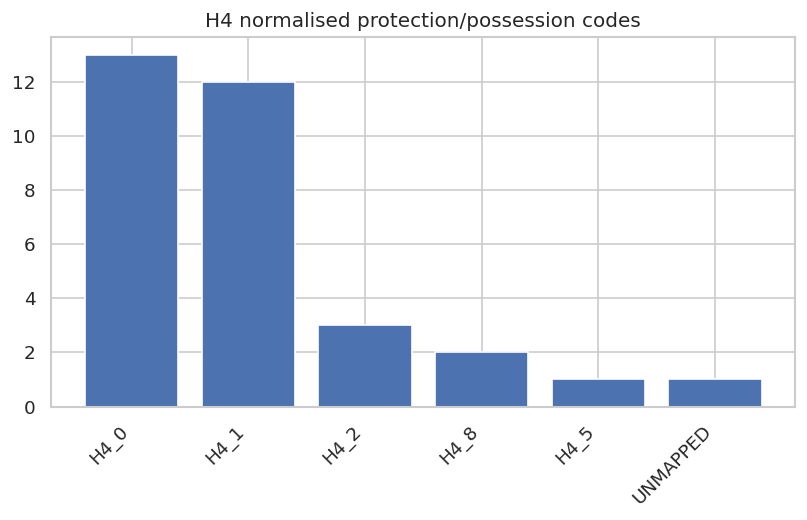

In [6]:
review_ids = rd.select_review_topics(
    h4,
    hyp=HYP,
    lex_idx=lex_idx,
    ctx_idx=ctx_idx,
    adj_idx=adj_idx,
    force_ids=ids_47,
    per_code=3,
    seed=42,
)
packs = rd.show_review_set(
    cfg,
    h4,
    review_ids,
    hyp=HYP,
    lex_idx=lex_idx,
    ctx_idx=ctx_idx,
    adj_idx=adj_idx,
    code_col=CODE_COL,
    max_sentences=12,
)
ctx.save_markdown(
    rd.render_review_markdown(
        packs, title="H4 protection / possession — close-reading pack"
    ),
    "close_reading_pack",
)
ctx.save_table(
    h4[
        [
            "topic_id",
            "current_topic_label",
            "current_taxonomy_id",
            "current_taxonomy_name",
            "care_protection_code",
            "code_norm",
            "mixed_topic",
        ]
    ],
    "care_protection_topic_annotations",
)

fig, ax = plt.subplots(figsize=(8, 4))
vc = h4["code_norm"].fillna("UNMAPPED").value_counts()
ax.bar(vc.index.astype(str), vc.values)
ax.set_title("H4 normalised protection/possession codes")
plt.xticks(rotation=45, ha="right")
ctx.save_figure(fig, "h4_code_distribution")
plt.show()

Primary refined contrast later: external_protection / (possessive_claiming +
coercive_control). If either side stays extremely sparse → H4 underpowered.

print("H4 audit review complete.")